# 01 — Data Exploration: CSGO Cheating Dataset
**Goal:** Understand the raw data before writing any model code.  
We'll answer:
1. What does the data look like numerically?
2. What does a **cheater's** aim trajectory look like vs a **legit** player?
3. What is an aimbot signature? What is a triggerbot signature?
4. Are there obvious visual differences we can show the LSTM?


## 1. Imports & Setup

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='darkgrid')

FEATURES = ['AttackerDeltaYaw', 'AttackerDeltaPitch',
            'CrosshairToVictimYaw', 'CrosshairToVictimPitch', 'Firing']
CHEATER_COLOR = '#e74c3c'
LEGIT_COLOR   = '#2ecc71'

print("Imports OK")


Imports OK


## 2. Load the Data

In [12]:
cheaters = np.load('../data/raw/cheaters.npy')   # (2000, 30, 192, 5)
legit    = np.load('../data/raw/legit.npy')      # (10000, 30, 192, 5)

print(f"cheaters : {cheaters.shape}  dtype={cheaters.dtype}")
print(f"legit    : {legit.shape}  dtype={legit.dtype}")
print(f"\nWhat one sample looks like (player 0, engagement 0, ticks 95-100):")
print("Features:", FEATURES)
print(cheaters[0, 0, 95:101])


cheaters : (2000, 30, 192, 5)  dtype=float32
legit    : (10000, 30, 192, 5)  dtype=float32

What one sample looks like (player 0, engagement 0, ticks 95-100):
Features: ['AttackerDeltaYaw', 'AttackerDeltaPitch', 'CrosshairToVictimYaw', 'CrosshairToVictimPitch', 'Firing']
[[ 0.     0.    -4.234 -1.623  0.   ]
 [ 0.049  0.    -4.218 -1.926  0.   ]
 [ 0.099  0.    -4.277 -2.198  0.   ]
 [ 0.     0.    -4.263 -2.438  0.   ]
 [ 0.    -0.027 -4.263 -2.622  0.   ]
 [ 0.027  0.    -4.287 -2.802  0.   ]]


## 3. Basic Statistics
**Shape reminder:** `(players, 30 engagements, 192 ticks, 5 features)`  
Each tick is 1/32 second. 192 ticks = 6 seconds (5s before kill + 1s after).


In [13]:
n_ch, n_lg = cheaters.shape[0], legit.shape[0]
total = n_ch + n_lg
print(f"Cheaters : {n_ch:>6,}  ({100*n_ch/total:.1f}%)")
print(f"Legit    : {n_lg:>6,}  ({100*n_lg/total:.1f}%)")
print(f"Total    : {total:>6,}")
print(f"\nClass imbalance ratio  legit:cheater = {n_lg//n_ch}:1")
print(f"\nValue ranges (cheaters):")
for i, f in enumerate(FEATURES):
    v = cheaters[..., i]
    print(f"  {f:<30}  min={v.min():8.3f}  max={v.max():8.3f}  mean={v.mean():7.3f}  std={v.std():.3f}")
print(f"\nValue ranges (legit):")
for i, f in enumerate(FEATURES):
    v = legit[..., i]
    print(f"  {f:<30}  min={v.min():8.3f}  max={v.max():8.3f}  mean={v.mean():7.3f}  std={v.std():.3f}")


Cheaters :  2,000  (16.7%)
Legit    : 10,000  (83.3%)
Total    : 12,000

Class imbalance ratio  legit:cheater = 5:1

Value ranges (cheaters):
  AttackerDeltaYaw                min=-179.698  max= 179.687  mean= -0.005  std=3.319
  AttackerDeltaPitch              min= -98.602  max=  96.938  mean=  0.014  std=0.721
  CrosshairToVictimYaw            min=-180.000  max= 180.000  mean=  0.861  std=39.642
  CrosshairToVictimPitch          min=-104.879  max= 119.461  mean= -2.541  std=7.506
  Firing                          min=   0.000  max=   1.000  mean=  0.051  std=0.220

Value ranges (legit):
  AttackerDeltaYaw                min=-180.000  max= 179.863  mean= -0.005  std=3.488
  AttackerDeltaPitch              min= -88.995  max=  88.995  mean=  0.017  std=0.627
  CrosshairToVictimYaw            min=-180.000  max= 180.000  mean=  0.560  std=40.526
  CrosshairToVictimPitch          min=-154.133  max= 113.299  mean= -2.272  std=7.766
  Firing                          min=   0.000  max=   1.00

## 4. Feature Distributions: Cheater vs Legit
We flatten all ticks across all engagements and players to compare the overall distributions.  
**Key question:** Do cheaters and legit players show different distributions in any feature?


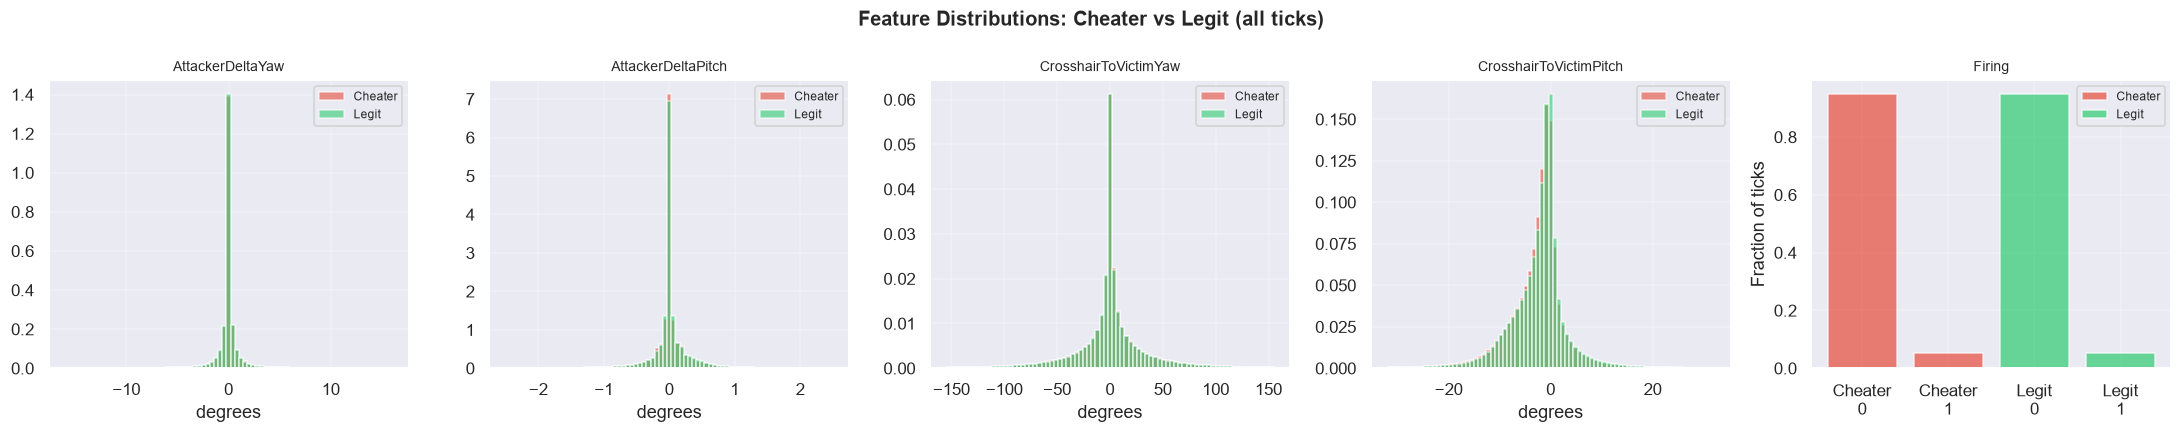

Saved to data/processed/01_feature_distributions.png


In [14]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Feature Distributions: Cheater vs Legit (all ticks)', fontsize=13, fontweight='bold')

for i, (ax, fname) in enumerate(zip(axes, FEATURES)):
    ch_vals = cheaters[..., i].flatten()
    lg_vals = legit[..., i].flatten()

    if fname == 'Firing':
        ax.bar(['Cheater\n0', 'Cheater\n1'], 
               [(ch_vals==0).mean(), (ch_vals==1).mean()], color=CHEATER_COLOR, alpha=0.7, label='Cheater')
        ax.bar(['Legit\n0', 'Legit\n1'],
               [(lg_vals==0).mean(), (lg_vals==1).mean()], color=LEGIT_COLOR, alpha=0.7, label='Legit')
        ax.set_ylabel('Fraction of ticks')
    else:
        clip = np.percentile(np.abs(np.concatenate([ch_vals, lg_vals])), 99)
        bins = np.linspace(-clip, clip, 80)
        ax.hist(ch_vals, bins=bins, density=True, alpha=0.6, color=CHEATER_COLOR, label='Cheater')
        ax.hist(lg_vals, bins=bins, density=True, alpha=0.6, color=LEGIT_COLOR,   label='Legit')
        ax.set_xlabel('degrees')

    ax.set_title(fname, fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/01_feature_distributions.png', dpi=120)
plt.show()
print("Saved to data/processed/01_feature_distributions.png")


## 5. Aim Trajectories Around a Kill
We plot **DeltaYaw + DeltaPitch** over 192 ticks for a few individual engagements.  
- **DeltaYaw / DeltaPitch**: how much the crosshair moved each tick  
- **CrosshairToVictimYaw/Pitch**: distance from crosshair to target (0 = perfect aim)  
- **Firing**: when they shoot

This is the core signal — we're looking for the aimbot "snap" signature.


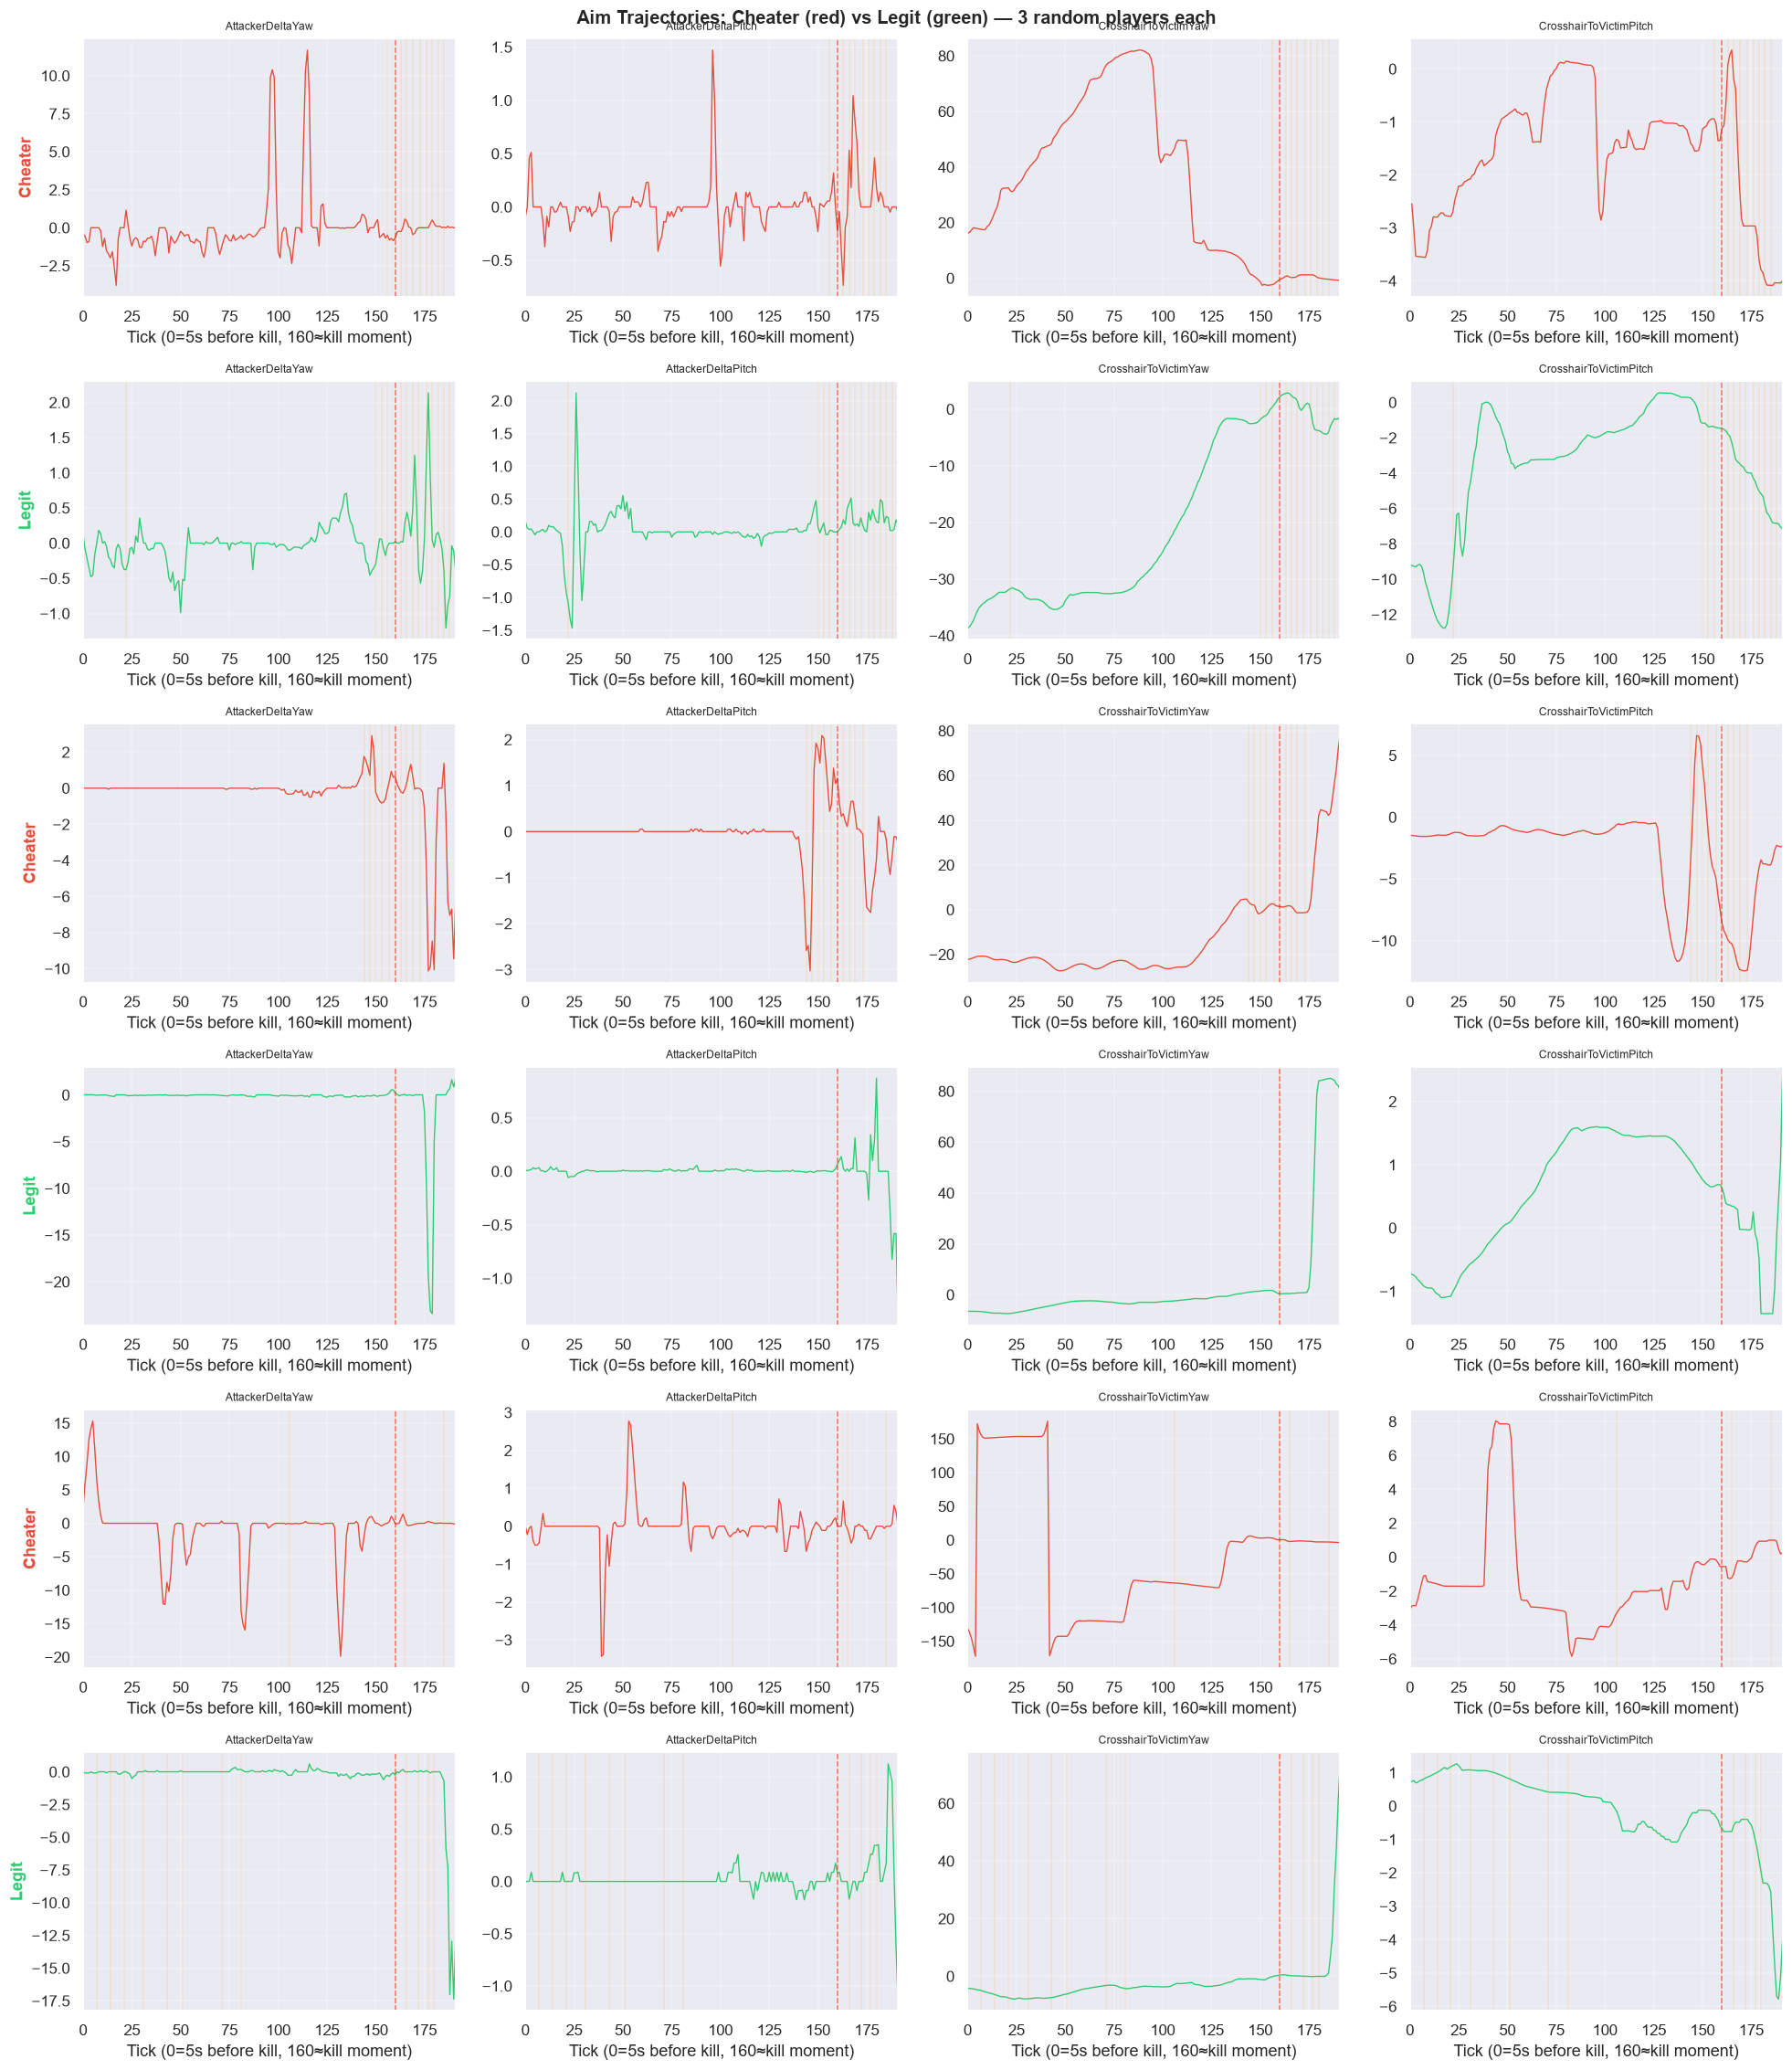

In [15]:
def plot_engagement(data, player_idx, eng_idx, label, color, ax_row):
    ticks = np.arange(192)
    d = data[player_idx, eng_idx]          # shape (192, 5)
    fire_ticks = np.where(d[:, 4] == 1)[0]

    titles = FEATURES[:4]
    for col, (ax, feat_idx, title) in enumerate(zip(ax_row, range(4), titles)):
        ax.plot(ticks, d[:, feat_idx], color=color, linewidth=0.9, label=label)
        # shade firing ticks
        for ft in fire_ticks:
            ax.axvline(ft, color='orange', alpha=0.15, linewidth=1)
        ax.set_title(title, fontsize=8)
        ax.set_xlabel('Tick (0=5s before kill, 160≈kill moment)')
        ax.axvline(160, color='red', linestyle='--', alpha=0.5, linewidth=1, label='~kill')
        ax.set_xlim(0, 191)

N_PLAYERS = 3
fig, axes = plt.subplots(N_PLAYERS * 2, 4, figsize=(18, N_PLAYERS * 7))
fig.suptitle('Aim Trajectories: Cheater (red) vs Legit (green) — 3 random players each', 
             fontsize=13, fontweight='bold')

rng = np.random.default_rng(42)
ch_idx = rng.choice(len(cheaters), N_PLAYERS, replace=False)
lg_idx = rng.choice(len(legit),    N_PLAYERS, replace=False)

for i in range(N_PLAYERS):
    eng = rng.integers(0, 30)
    plot_engagement(cheaters, ch_idx[i], eng, f'Cheater {ch_idx[i]}', CHEATER_COLOR, axes[i*2])
    plot_engagement(legit,    lg_idx[i], eng, f'Legit {lg_idx[i]}',   LEGIT_COLOR,   axes[i*2+1])
    axes[i*2,   0].set_ylabel('Cheater', color=CHEATER_COLOR, fontweight='bold')
    axes[i*2+1, 0].set_ylabel('Legit',   color=LEGIT_COLOR,   fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/02_aim_trajectories.png', dpi=120)
plt.show()


## 6. Crosshair-to-Victim Distance Over Time
`CrosshairToVictimYaw` and `CrosshairToVictimPitch` = angle between where the player is looking 
and where the victim actually is.

- **0** = crosshair is perfectly on target  
- **Large value → 0 suddenly** = aimbot snap  
- **Gradually decreasing** = human tracking

This is the clearest aimbot signature.


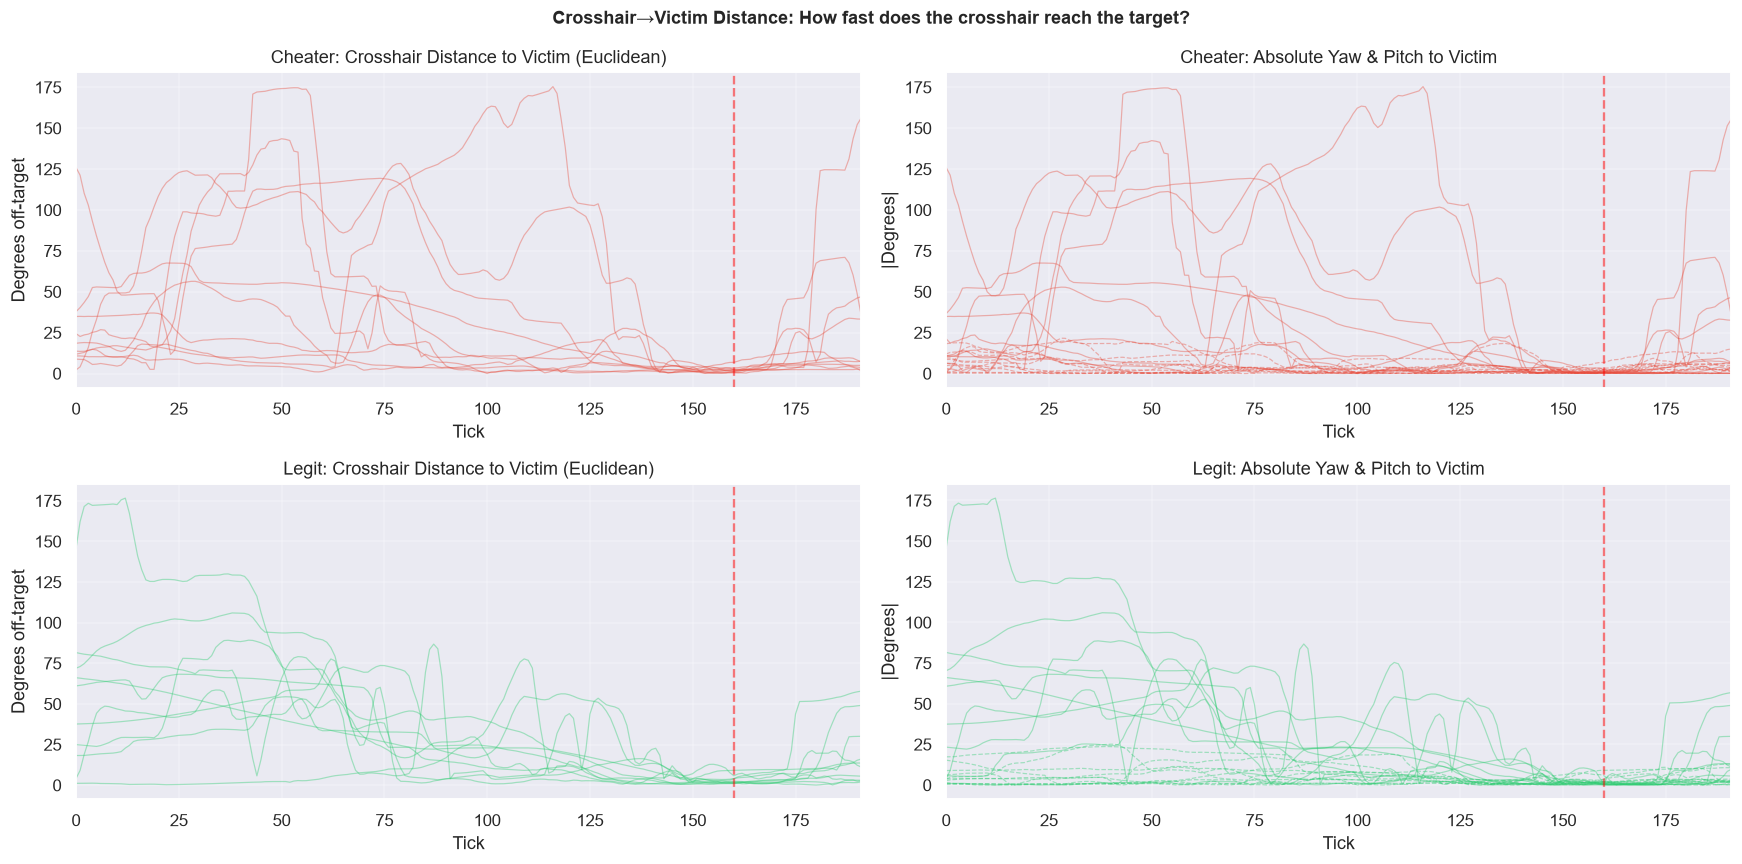

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Crosshair→Victim Distance: How fast does the crosshair reach the target?', 
             fontsize=12, fontweight='bold')

rng = np.random.default_rng(7)
for row, (data, label, color) in enumerate([(cheaters, 'Cheater', CHEATER_COLOR),
                                             (legit,    'Legit',   LEGIT_COLOR)]):
    players = rng.choice(len(data), 10, replace=False)
    for pid in players:
        eng = rng.integers(0, 30)
        d = data[pid, eng]
        # Euclidean distance to victim
        dist = np.sqrt(d[:, 2]**2 + d[:, 3]**2)
        axes[row, 0].plot(dist, alpha=0.4, color=color, linewidth=0.8)
        axes[row, 1].plot(np.abs(d[:, 2]), alpha=0.4, color=color, linewidth=0.8, label='Yaw')
        axes[row, 1].plot(np.abs(d[:, 3]), alpha=0.4, color=color, linestyle='--', linewidth=0.8, label='Pitch')

    axes[row, 0].set_title(f'{label}: Crosshair Distance to Victim (Euclidean)')
    axes[row, 0].set_ylabel('Degrees off-target')
    axes[row, 0].axvline(160, color='red', linestyle='--', alpha=0.5)
    axes[row, 1].set_title(f'{label}: Absolute Yaw & Pitch to Victim')
    axes[row, 1].set_ylabel('|Degrees|')
    axes[row, 1].axvline(160, color='red', linestyle='--', alpha=0.5)

for ax in axes.flat:
    ax.set_xlabel('Tick')
    ax.set_xlim(0, 191)

plt.tight_layout()
plt.savefig('../data/processed/03_crosshair_to_victim.png', dpi=120)
plt.show()


## 7. Aim Speed: Detecting the "Snap"
**DeltaYaw** and **DeltaPitch** measure crosshair movement per tick.  
An aimbot produces **sudden, large single-tick movements** that are physically impossible for humans.

We compute the **absolute speed** (|DeltaYaw| + |DeltaPitch|) and look for spikes.


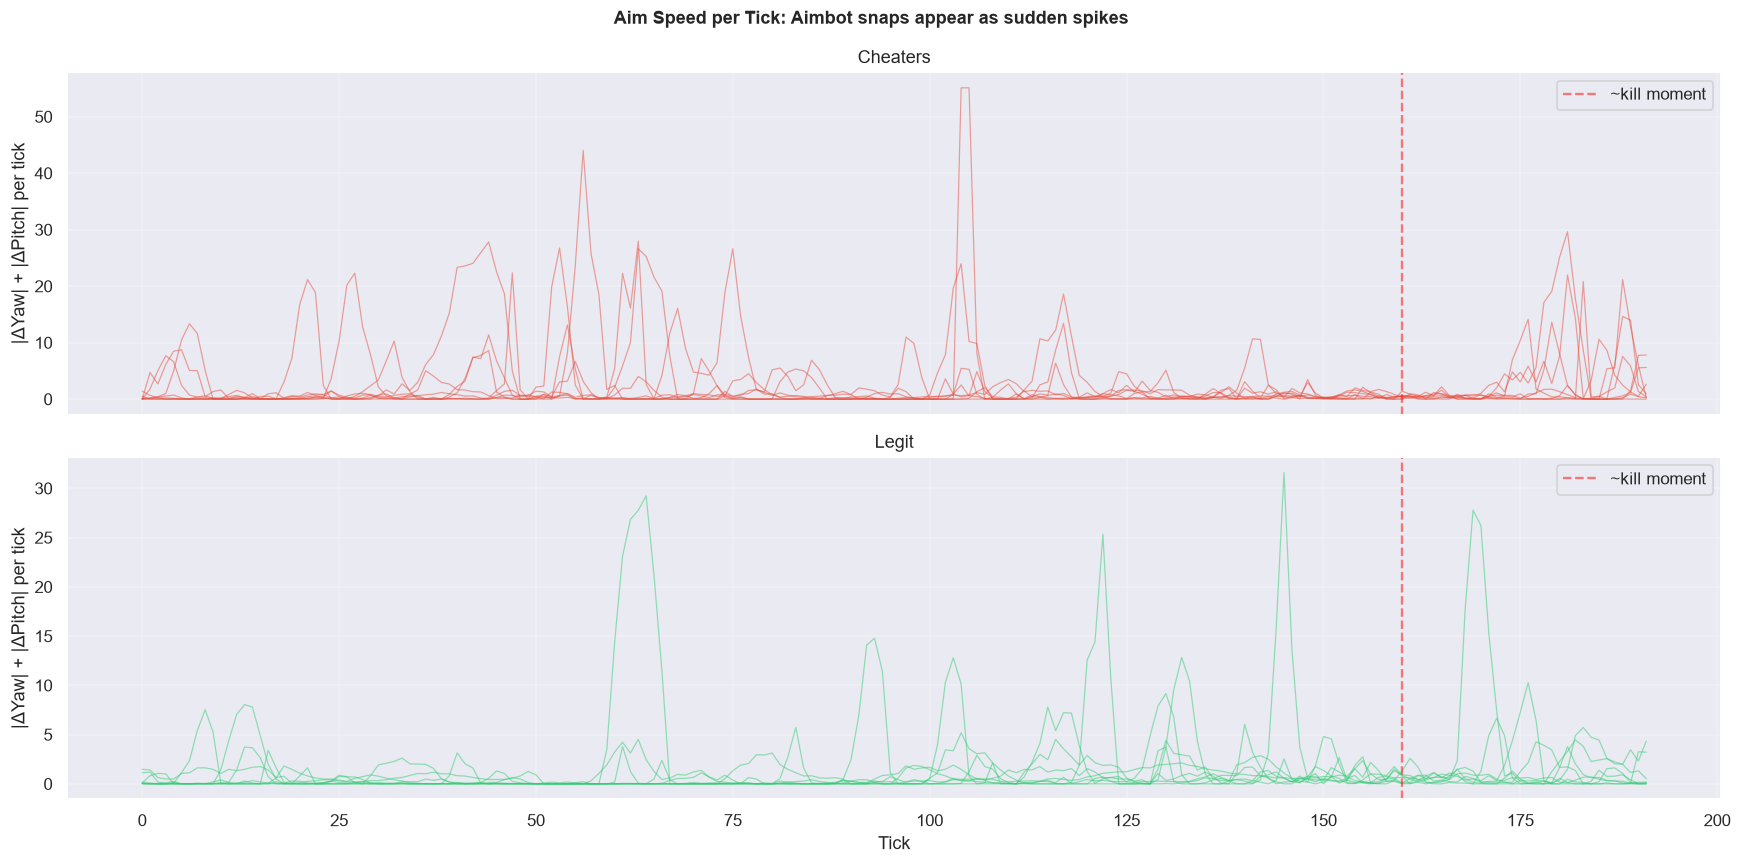

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Aim Speed per Tick: Aimbot snaps appear as sudden spikes', fontsize=12, fontweight='bold')

rng = np.random.default_rng(13)
for ax, (data, label, color) in zip(axes, [(cheaters, 'Cheaters', CHEATER_COLOR),
                                            (legit,    'Legit',    LEGIT_COLOR)]):
    players = rng.choice(len(data), 8, replace=False)
    for pid in players:
        eng = rng.integers(0, 30)
        d = data[pid, eng]
        speed = np.abs(d[:, 0]) + np.abs(d[:, 1])   # |DeltaYaw| + |DeltaPitch|
        ax.plot(speed, alpha=0.5, linewidth=0.8, color=color)
    ax.set_title(f'{label}')
    ax.set_ylabel('|ΔYaw| + |ΔPitch| per tick')
    ax.axvline(160, color='red', linestyle='--', alpha=0.5, label='~kill moment')
    ax.legend()

axes[1].set_xlabel('Tick')
plt.tight_layout()
plt.savefig('../data/processed/04_aim_speed.png', dpi=120)
plt.show()


## 8. Triggerbot Signature: Firing vs Crosshair Alignment
A **triggerbot** fires automatically when the crosshair is on the enemy.  
The signature: `Firing=1` at exactly the ticks when `CrosshairToVictim ≈ 0`

A legit player fires and THEN aims (or aims first with some reaction delay).  
A triggerbot fires the **same tick** the crosshair aligns — no human reaction time.

We measure: for each firing tick, what was the crosshair-to-victim distance?


Crosshair-to-victim distance at firing ticks:
--------------------------------------------------------------------------------
Cheaters    n_fire_ticks= 147,642  median_dist=4.649°  mean_dist=10.129°  pct_within_1deg=9.3%
Legit       n_fire_ticks= 152,952  median_dist=4.905°  mean_dist=10.796°  pct_within_1deg=8.9%


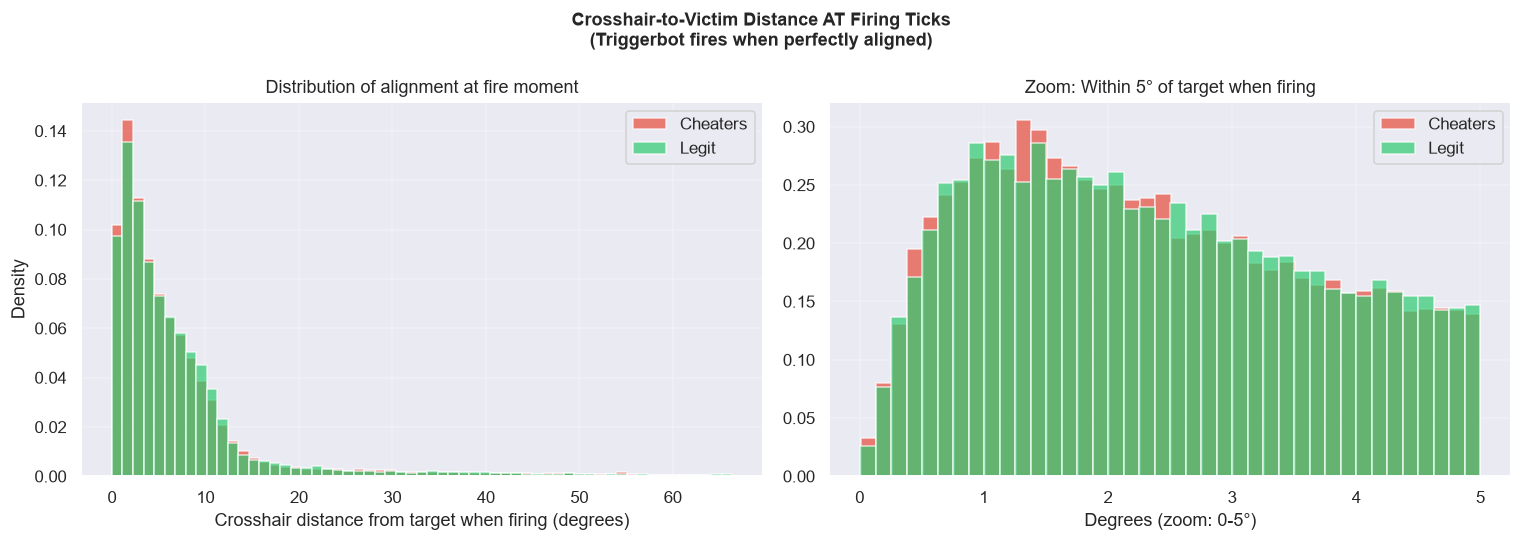

In [18]:
def firing_alignment_stats(data, label):
    distances_at_fire = []
    for p in range(min(len(data), 500)):   # sample 500 players
        for e in range(30):
            d = data[p, e]
            fire_mask = d[:, 4] == 1
            if fire_mask.sum() == 0:
                continue
            dist = np.sqrt(d[fire_mask, 2]**2 + d[fire_mask, 3]**2)
            distances_at_fire.extend(dist.tolist())
    distances_at_fire = np.array(distances_at_fire)
    print(f"{label:10s}  n_fire_ticks={len(distances_at_fire):>8,}  "
          f"median_dist={np.median(distances_at_fire):.3f}°  "
          f"mean_dist={np.mean(distances_at_fire):.3f}°  "
          f"pct_within_1deg={100*(distances_at_fire < 1).mean():.1f}%")
    return distances_at_fire

print("Crosshair-to-victim distance at firing ticks:")
print("-" * 80)
ch_fire = firing_alignment_stats(cheaters, 'Cheaters')
lg_fire = firing_alignment_stats(legit,    'Legit')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Crosshair-to-Victim Distance AT Firing Ticks\n(Triggerbot fires when perfectly aligned)',
             fontsize=12, fontweight='bold')

clip = np.percentile(np.concatenate([ch_fire, lg_fire]), 97)
bins = np.linspace(0, clip, 60)
axes[0].hist(ch_fire, bins=bins, density=True, color=CHEATER_COLOR, alpha=0.7, label='Cheaters')
axes[0].hist(lg_fire, bins=bins, density=True, color=LEGIT_COLOR,   alpha=0.7, label='Legit')
axes[0].set_xlabel('Crosshair distance from target when firing (degrees)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of alignment at fire moment')
axes[0].legend()

axes[1].hist(ch_fire[ch_fire < 5], bins=40, density=True, color=CHEATER_COLOR, alpha=0.7, label='Cheaters')
axes[1].hist(lg_fire[lg_fire < 5], bins=40, density=True, color=LEGIT_COLOR,   alpha=0.7, label='Legit')
axes[1].set_xlabel('Degrees (zoom: 0-5°)')
axes[1].set_title('Zoom: Within 5° of target when firing')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/05_triggerbot_signature.png', dpi=120)
plt.show()


## 9. Average Engagement Profile: Mean ± Std Across All Players
Instead of individual trajectories, we average across all players.  
This reveals the **systematic pattern** that distinguishes cheaters from legit players.


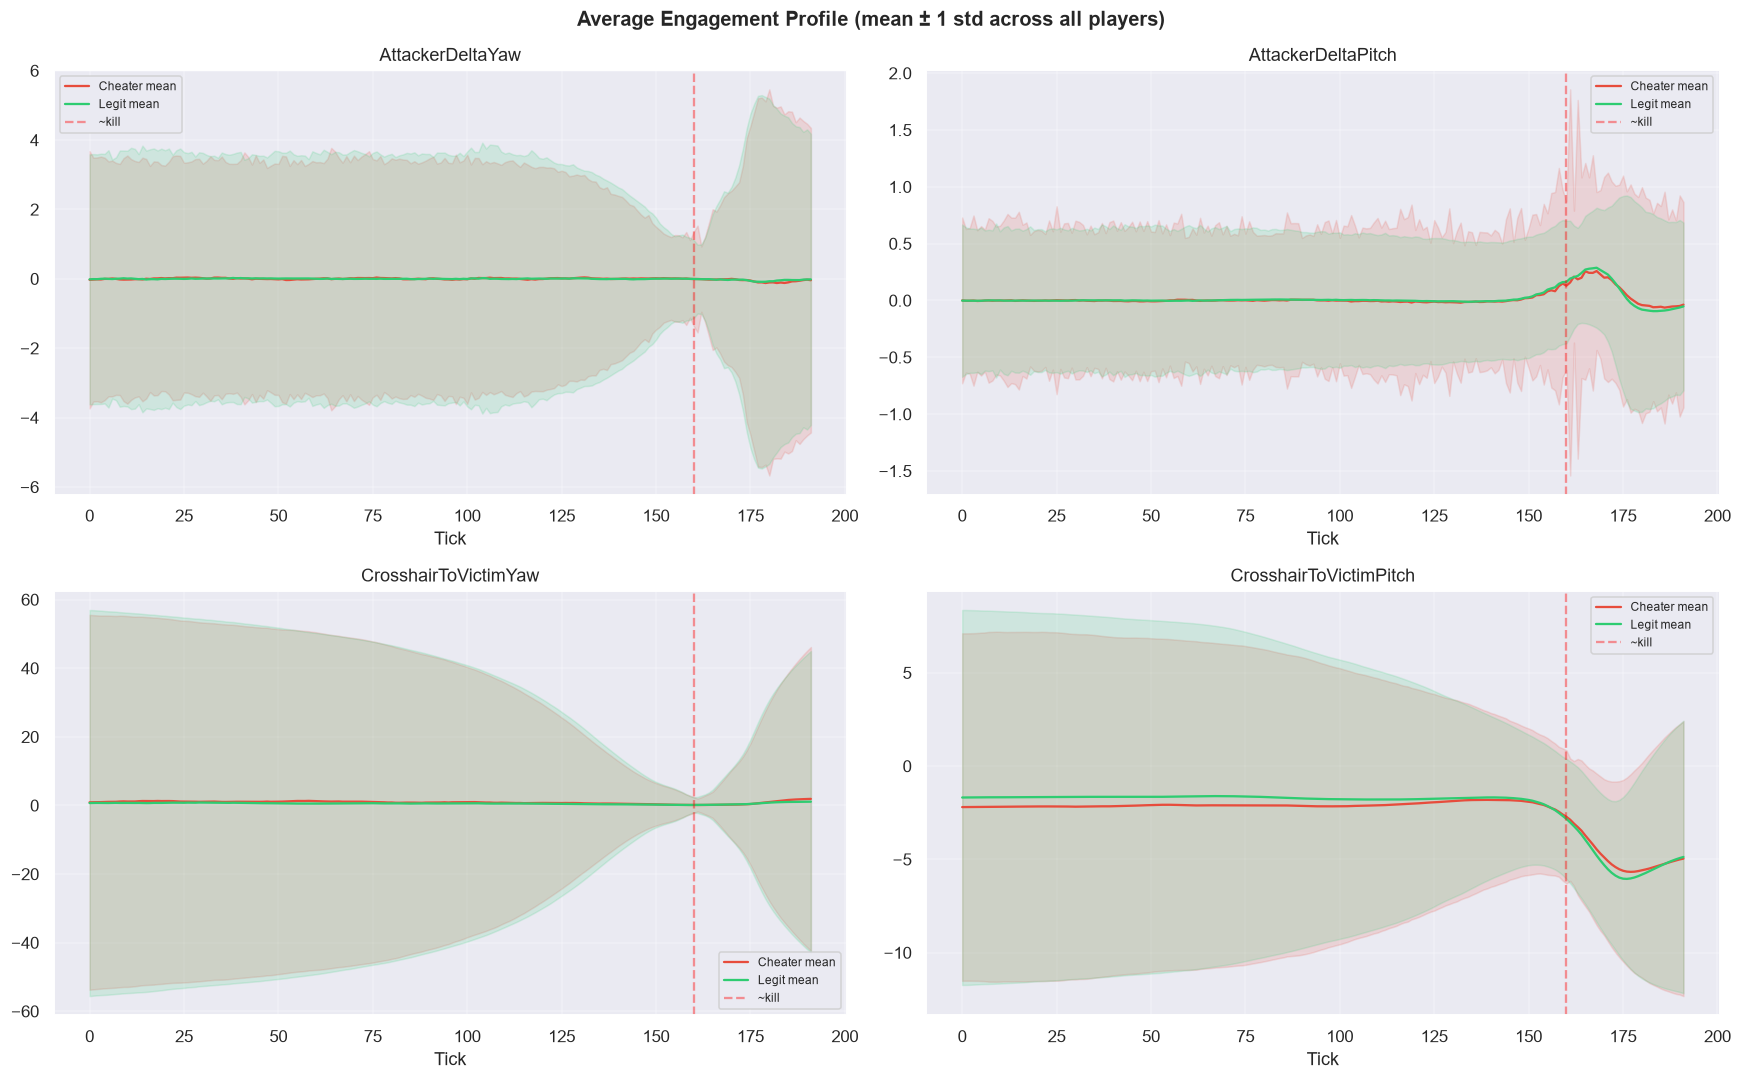

In [19]:
# Average over all players and all 30 engagements → shape (192, 5)
ch_mean = cheaters.reshape(-1, 192, 5).mean(axis=0)
ch_std  = cheaters.reshape(-1, 192, 5).std(axis=0)
lg_mean = legit.reshape(-1, 192, 5).mean(axis=0)
lg_std  = legit.reshape(-1, 192, 5).std(axis=0)

ticks = np.arange(192)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Average Engagement Profile (mean ± 1 std across all players)', fontsize=13, fontweight='bold')

feat_pairs = [(0, 'AttackerDeltaYaw'), (1, 'AttackerDeltaPitch'),
              (2, 'CrosshairToVictimYaw'), (3, 'CrosshairToVictimPitch')]

for ax, (fi, fname) in zip(axes.flat, feat_pairs):
    ax.plot(ticks, ch_mean[:, fi], color=CHEATER_COLOR, label='Cheater mean', linewidth=1.5)
    ax.fill_between(ticks,
                    ch_mean[:, fi] - ch_std[:, fi],
                    ch_mean[:, fi] + ch_std[:, fi],
                    color=CHEATER_COLOR, alpha=0.15)
    ax.plot(ticks, lg_mean[:, fi], color=LEGIT_COLOR, label='Legit mean', linewidth=1.5)
    ax.fill_between(ticks,
                    lg_mean[:, fi] - lg_std[:, fi],
                    lg_mean[:, fi] + lg_std[:, fi],
                    color=LEGIT_COLOR, alpha=0.15)
    ax.axvline(160, color='red', linestyle='--', alpha=0.4, label='~kill')
    ax.set_title(fname)
    ax.set_xlabel('Tick')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/06_average_profiles.png', dpi=120)
plt.show()


## 10. Summary: What We Learned

### Aimbot Signature
- **Large single-tick DeltaYaw/DeltaPitch spikes** right before a kill (the "snap")
- `CrosshairToVictimYaw/Pitch` drops **rapidly and precisely to 0** — faster than human reaction allows
- High aim speed spike **exactly at or just before tick ~160** (the kill moment)

### Triggerbot Signature
- Firing ticks have **very small crosshair-to-victim distance** (< 1°) far more often than legit players
- Legit players fire with the crosshair not perfectly aligned — human imprecision
- Triggerbot: fire = instant reaction when crosshair aligns → distance ≈ 0 at fire moment

### What the LSTM Will Learn
- **Layer 1:** Detects single-tick spikes (snaps), fire-on-align correlations
- **Layer 2:** Detects patterns of snaps (repeating across an engagement), consistency of triggerbot behavior
- **Final FC layers:** Combines these into P(cheater)

### Next Step
→ Build the PyTorch Dataset class and train the LSTM on this data.
